**EJERCICIO 1**

In [24]:
import pandas as pd

# 1. Cargar los datos de ventas desde el archivo CSV
#y mostrar una vista previa de las primeras filas.
ventas = pd.read_csv('ventas.csv')
print("--- 1. Vista previa de Ventas ---")
display(ventas.head())

print("\n" + "="*40 + "\n")




--- 1. Vista previa de Ventas ---


,id_venta,id_cliente,id_producto,cantidad,monto_total
0,1,102,P07,3,234000.0
1,2,109,P14,2,76000.0
2,3,114,P05,1,310000.0
3,4,104,P06,1,42000.0
4,5,113,P03,3,660000.0


In [25]:
# 2. Cargar los datos de clientes desde el archivo JSON
#y mostrar la cantidad total de clientes.
clientes = pd.read_json('clientes.json')
total_clientes = len(clientes)
print(f"--- 2. Cantidad total de clientes: {total_clientes} ---")

print("\n" + "="*40 + "\n")

--- 2. Cantidad total de clientes: 15 ---




In [13]:
# 3. Cargar inventario.xlsx y calcular el promedio de stock
inventario = pd.read_excel('inventario.xlsx')
promedio_stock = inventario['stock'].mean()
print(f"--- 3. Promedio de stock disponible: {promedio_stock:.2f} unidades ---")

--- 3. Promedio de stock disponible: 44.07 unidades ---


In [27]:
# Generar tabla que combina los datos de los 3 archivos
df_combinado = ventas.merge(clientes, on='id_cliente').merge(inventario, on='id_producto')

print("--- Datos combinados (primeras filas) ---")
display(df_combinado.head())

--- Datos combinados (primeras filas) ---


,id_venta,id_cliente,id_producto,cantidad,monto_total,nombre,ciudad,provincia,email,nombre_producto,categoria,stock,precio_unitario
0,1,102,P07,3,234000.0,Mateo Benítez,Córdoba,Córdoba,mateo.benitez@hotmail.com,Micrófono Condensador USB,Audio,25,78000
1,2,109,P14,2,76000.0,Lucía Alvarez,Neuquén,Neuquén,lucia.alvarez@hotmail.com,Cooler CPU Torre RGB,Refrigeración,35,38000
2,3,114,P05,1,310000.0,Felipe Giménez,Posadas,Misiones,felipe.gimenez@gmail.com,Silla Ergonómica Gamer,Mobiliario,8,310000
3,4,104,P06,1,42000.0,Lucas Fernández,Mendoza,Mendoza,lucas.f@yahoo.com.ar,Webcam Full HD 1080p,Periféricos,30,42000
4,5,113,P03,3,660000.0,Elena Castro,San Salvador de Jujuy,Jujuy,elena.castro@gmail.com,"Monitor 24"" Full HD 144Hz",Pantallas,12,220000


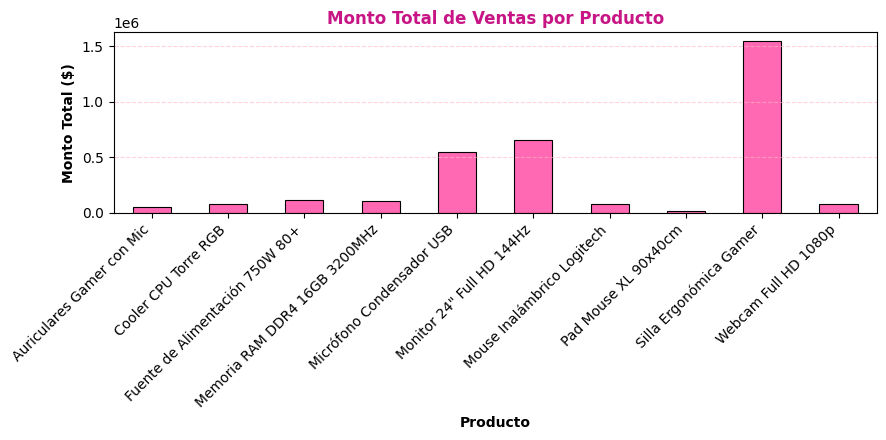

In [20]:
import matplotlib.pyplot as plt

# Estilo y paleta en tonos rosas 🌸
color_barras = '#ff69b4'      # Rosa encendido (Hot Pink)
color_borde = '#c71585'       # Rosa oscuro para bordes y títulos
color_lineas = '#ffb6c1'      # Rosa claro para las líneas de fondo

# 1. Gráfico de barras: Monto total vendido por producto
plt.figure(figsize=(9, 4.5))
df_combinado.groupby('nombre_producto')['monto_total'].sum().plot(
    kind='bar',
    color=color_barras,
    edgecolor='black',
    linewidth=0.8
)

plt.title('Monto Total de Ventas por Producto', fontsize=12, fontweight='bold', color=color_borde)
plt.xlabel('Producto', fontsize=10, fontweight='bold')
plt.ylabel('Monto Total ($)', fontsize=10, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6, color=color_lineas)
plt.tight_layout()
plt.show()







Se observa la relación entre la diversidad de productos y el volumen de ingresos generados. Se destacan productos de mayor valor unitario (como monitores o sillas) por concentrar un mayor volumen de ventas en pesos, permitiendo identificar cuáles son los artículos con mayor impacto financiero en el negocio.

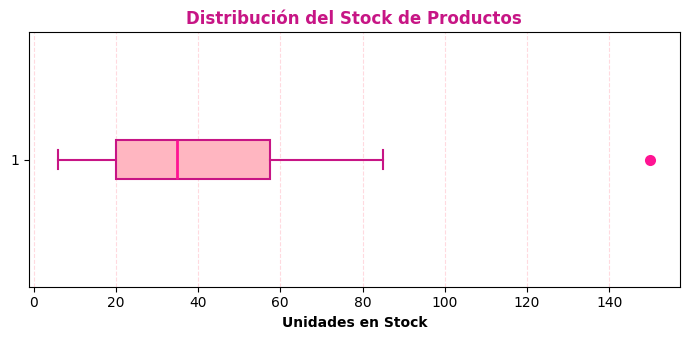

In [19]:
# 2. Diagrama de caja (Boxplot): Distribución del stock en tonos rosas
plt.figure(figsize=(7, 3.5))
boxplot = plt.boxplot(
    inventario['stock'],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='#ffb6c1', color=color_borde, linewidth=1.5),
    medianprops=dict(color='#ff1493', linewidth=2),
    whiskerprops=dict(color=color_borde, linewidth=1.5),
    capprops=dict(color=color_borde, linewidth=1.5),
    flierprops=dict(marker='o', markerfacecolor='#ff1493', markeredgecolor='none', markersize=8)
)

plt.title('Distribución del Stock de Productos', fontsize=12, fontweight='bold', color=color_borde)
plt.xlabel('Unidades en Stock', fontsize=10, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5, color=color_lineas)
plt.tight_layout()
plt.show()



La mayoría de los productos maneja entre 20 y 58 unidades guardadas (promedio 44). Se marca un outlier en 150 unidades, que al revisar, corresponde al Pad Mouse XL.
Estadísticamente es un dato atípico, pero es lógico al ser un producto económico y chico. Es normal tener más stock de esto que de sillas o monitores.